In [3]:
# Improve Chart Styling - Better Polish

# Get sector for each company (join back)
company_sector = df.groupby("Company")["sector"].first()
cagr_with_sector = pd.DataFrame({
    "cagr": cagr_result,
    "sector": company_sector
}).sort_values("cagr", ascending=True)

# Define sector colours
sector_colors = {
    "Logistics": "#2E86AB",       # Blue
    "Technology": "#A23B72",      # Purple
    "FinTech": "#F18F01",         # Orange
    "Electronics": "#C73E1D",     # Red
    "Manufacturing": "#7A9E7E",   # Green
    "Food & Beverage": "#E5B181", # Tan
    "Banking": "#6B7280",         # Grey
    "Finance": "#1F2937",         # Dark grey
}

# Map colours
bar_colors = [sector_colors.get(s, "#999999") for s in cagr_with_sector["sector"]]

fig, ax = plt.subplots(figsize=(11, 8))

# Same chart code as Cell 9, plus:
fig.suptitle("Company CAGR by Sector — Revenue 2009-2022",
             fontsize=14, fontweight="bold", y=1.)

ax.set_title("Bimodal distribution: tech and logistics winners (top), "
             "banking and finance decliners (bottom)",
             fontsize=10, style="italic", pad=10)

ax.barh(cagr_with_sector.index, cagr_with_sector["cagr"], color=bar_colors, edgecolor="none")
ax.set_title("Company CAGR by Sector — Revenue 2009-2022", fontsize=14, fontweight="bold")
ax.set_xlabel("Compound Annual Growth Rate (%)", fontsize=11)
ax.axvline(x=0, color="black", linewidth=0.5)

# Value labels
for i, (company, cagr) in enumerate(zip(cagr_with_sector.index, cagr_with_sector["cagr"])):
    ax.text(cagr + (0.5 if cagr >= 0 else -0.5), i, f"{cagr:.1f}%", 
            va="center", ha="left" if cagr >= 0 else "right", fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=sector) 
                   for sector, color in sector_colors.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=1)

# Clean up
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-15, 34)

plt.tight_layout()
# After all your styling
import os
os.makedirs("outputs", exist_ok=True)

plt.savefig("outputs/cagr_ranking_python.png", dpi=300, bbox_inches="tight")
plt.show()


NameError: name 'df' is not defined

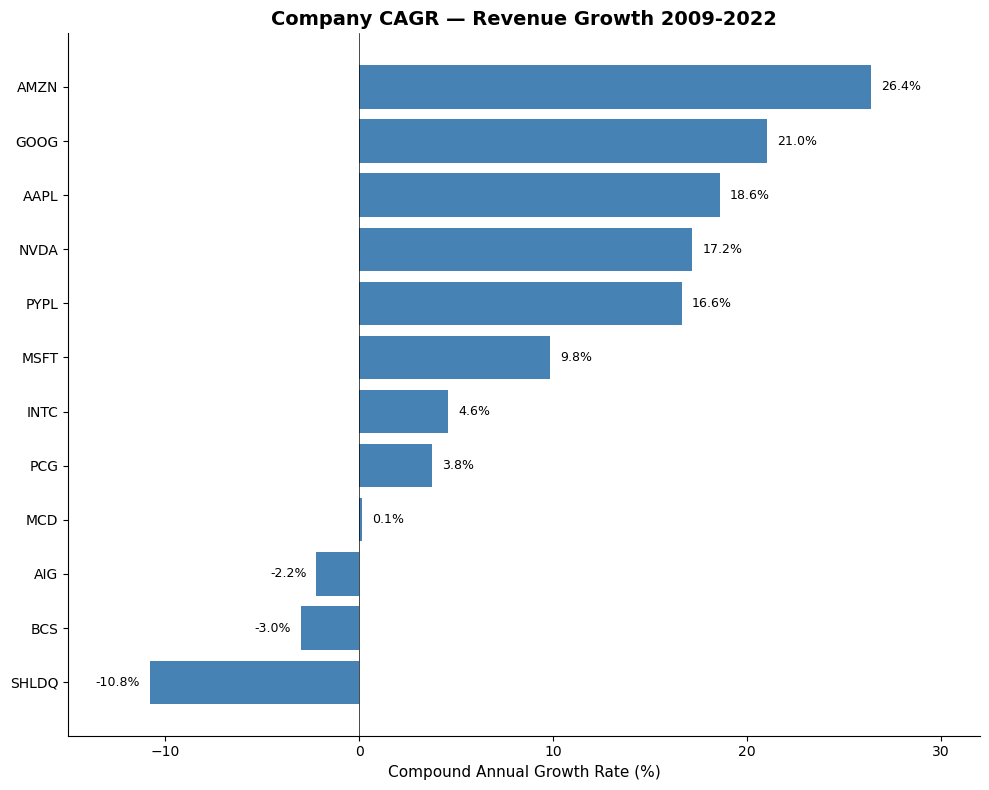

In [14]:
# Improve Visual Aspect of First Horizontal Bar Chart

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(cagr_result.index, cagr_result.values, color="steelblue", edgecolor="none")
ax.set_title("Company CAGR — Revenue Growth 2009-2022", fontsize=14, fontweight="bold")
ax.set_xlabel("Compound Annual Growth Rate (%)", fontsize=11)
ax.axvline(x=0, color="black", linewidth=0.5)   # Zero line for negative CAGRs

# Add value labels next to each bar
for i, (company, cagr) in enumerate(zip(cagr_result.index, cagr_result.values)):
    ax.text(cagr + (0.5 if cagr >= 0 else -0.5), i, f"{cagr:.1f}%", 
            va="center", 
            ha="left" if cagr >= 0 else "right",
            fontsize=9)

# Clean up
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-15, 32)

plt.tight_layout()
plt.show()

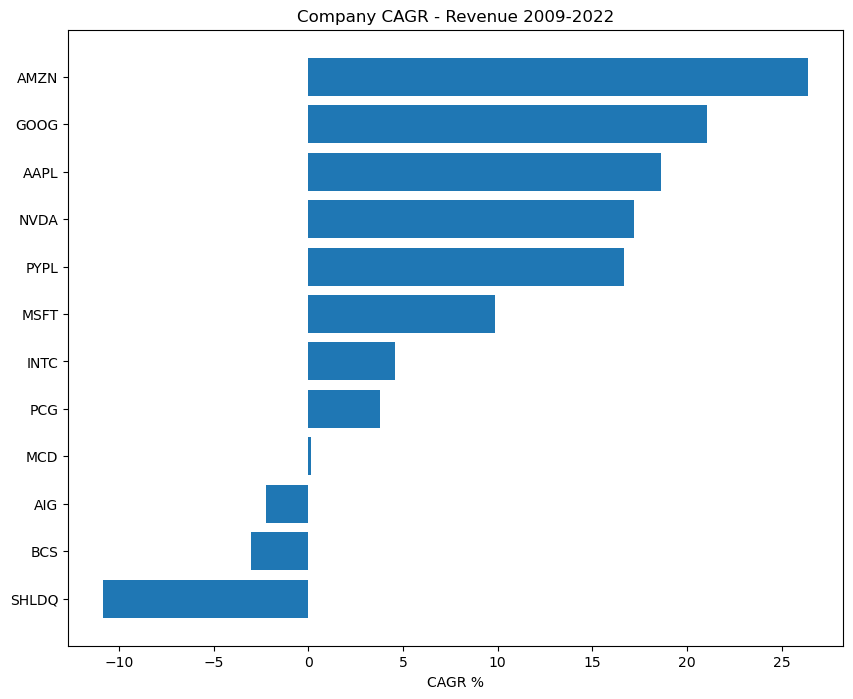

In [7]:
# First Horizontal Bar Chart

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(cagr_result.index, cagr_result.values)
ax.set_title("Company CAGR - Revenue 2009-2022")
ax.set_xlabel("CAGR %")

plt.show()

In [ ]:
# Compute CAGR per company
# CAGR Function

def compute_company_cagr(group):
    first_year_row = group.loc[group["Year"].idxmin()]
    last_year_row = group.loc[group["Year"].idxmax()]
    years = last_year_row["Year"] - first_year_row["Year"]
    if years == 0 or first_year_row["Revenue"] <= 0:
        return None
    return ((last_year_row["Revenue"] / first_year_row["Revenue"]) ** (1 / years) - 1) * 100

cagr_result = df.groupby("Company").apply(
    compute_company_cagr, include_groups=False
).round(2).sort_values(ascending=True)

cagr_result

Company
SHLDQ   -10.81
BCS      -3.02
AIG      -2.21
MCD       0.15
PCG       3.77
INTC      4.60
MSFT      9.85
PYPL     16.65
NVDA     17.18
AAPL     18.61
GOOG     21.03
AMZN     26.38
dtype: float64

In [ ]:
# Reproduce CAGR Ranking as Horizontal Bars - Initial Setup

from pathlib import Path

SCRIPT_DIR = Path().resolve()
df = pd.read_csv(SCRIPT_DIR / "data" / "Financial Statements.csv")
df.columns = df.columns.str.strip()

sector_map = {
    "IT": "Technology", "LOGI": "Logistics", "FOOD": "Food & Beverage",
    "BANK": "Banking", "ELEC": "Electronics", "FinTech": "FinTech",
    "Finance": "Finance", "Manufacturing": "Manufacturing",
}
df["sector"] = df["Category"].map(sector_map)
df = df[(df["Year"] >= 2009) & (df["Year"] <= 2022)]

print(df.shape)

(159, 24)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
# - Create the Container for the Chart
ax.bar(x, y) 
# - plot data
ax.set_xlabel("...") 
# - customise

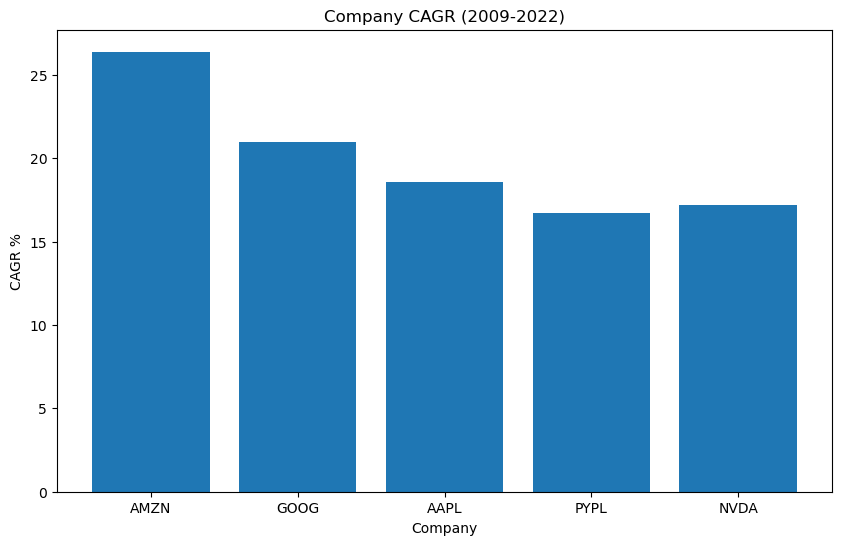

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
# Creates a figure (10 inches x 6 inches) with one axe (chart) inside it.
ax.bar(companies, cagrs)
ax.set_title("Company CAGR (2009-2022)")
ax.set_xlabel("Company")
ax.set_ylabel("CAGR %")

plt.show()

# Customise each Chart using OO Interface independently. 

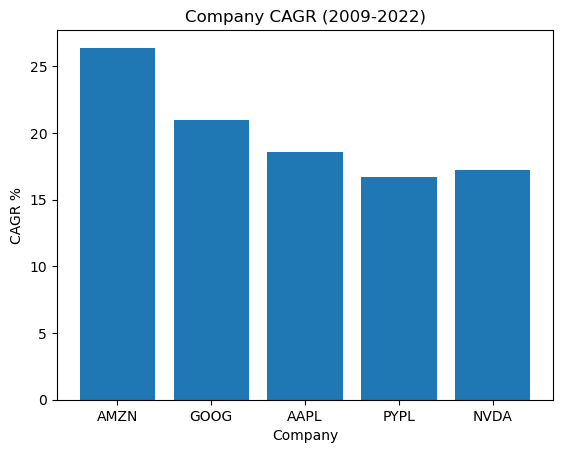

In [ ]:
# Add Basic Labels - Always add these Three.
plt.bar(companies, cagrs)
plt.title("Company CAGR (2009-2022)")
plt.xlabel("Company")
plt.ylabel("CAGR %")
plt.show()

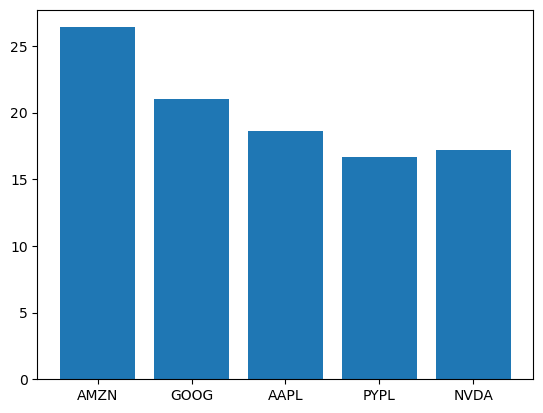

In [ ]:
import matplotlib.pyplot as plt 
# universal alias always plt
import pandas as pd

# Simple bar chart from a Python list
companies = ["AMZN", "GOOG", "AAPL", "PYPL", "NVDA"]
cagrs = [26.4, 21.0, 18.6, 16.7, 17.2]

plt.bar(companies, cagrs)
plt.show()